# Exploração de Dados: Mapeando o comportamento da variável alvo
Notebook focado em responder o que aconteceu a partir do dia 3/09, em que houve um aumento repentino de incidentes que não voltou a diminuir novamente.
Esse notebook da origem as tabelas:
s_volume (volumetria de incidentes)
s_temporal (features temporais)

## Configurações Iniciais

### Configurações a depender do ambiente

In [1]:
import os
import sys

IN_COLAB = 'google.colab' in sys.modules
ENV_NAME = "☁️ Google Colab" if IN_COLAB else "💻 Ambiente Local (WSL/Jupyter)"

print(f"Detectado: {ENV_NAME}")
print(f"Versão do Python: {sys.version.split()[0]}")

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = "/content/drive/MyDrive/fiap/segundo ano/challenge_locaweb/1_bronze_data/"
    SAVE_PATH = "/content/drive/MyDrive/fiap/segundo ano/challenge_locaweb/2_silver_data/"
else:
    BASE_PATH = "../1_bronze_data/"
    SAVE_PATH = "../2_silver_data/"

Detectado: 💻 Ambiente Local (WSL/Jupyter)
Versão do Python: 3.12.10


### Importação de Bibliotecas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import pyarrow.csv as pcsv
import pyarrow.dataset as ds
from scipy import stats
from pandas.tseries.holiday import AbstractHolidayCalendar, Holiday, Easter, Day
import ruptures as rpt

### Importação de Dados

In [3]:
pasta_csv = f"{BASE_PATH}b_incidentes.csv"
parse_options = pcsv.ParseOptions(delimiter=";")
read_options = pcsv.ReadOptions(encoding="ISO-8859-1")
dataset = ds.dataset(pasta_csv, format=ds.CsvFileFormat(parse_options=parse_options, read_options=read_options))
df = dataset.to_table().to_pandas()

In [4]:
df.head(5)

,Número,Prioridade,Produto,Categoria,Subcategoria,Grupo designado,Item de configuração,Aberto,Resolvido,Encerrado,...,Aberto por,Incidente Pai,Status,Entrou para KPI?,KPI Violado?,Tempo_Pos_Resolução,Resolvido_after_Encerrado,Duração_is_inconsistent,Diferença_Limite_Duração,Modified_Record
0,INC8654273,3 - Média,,,,Team14,IC00001,2025-12-31 23:45:18+00:00,NaT,2025-12-31 23:45:32+00:00,...,Monitoramento,,Sem Intervenção,NAO,N/A,NaN,False,False,-43186,False
1,INC8654270,4 - Baixa,,,,Team14,IC00002,2025-12-31 23:39:36+00:00,NaT,2025-12-31 23:43:05+00:00,...,Monitoramento,,Sem Intervenção,NAO,N/A,NaN,False,False,-86191,False
2,INC8654264,4 - Baixa,,,,Team14,,2025-12-31 23:23:10+00:00,NaT,2025-12-31 23:25:00+00:00,...,Monitoramento,,Sem Intervenção,NAO,N/A,NaN,False,False,-86290,False
3,INC8654263,4 - Baixa,,,,Team14,,2025-12-31 23:23:07+00:00,NaT,2025-12-31 23:24:57+00:00,...,Monitoramento,,Sem Intervenção,NAO,N/A,NaN,False,False,-86290,False
4,INC8654262,4 - Baixa,,,,Team14,IC00003,2025-12-31 23:23:05+00:00,NaT,2025-12-31 23:23:47+00:00,...,Monitoramento,,Sem Intervenção,NAO,N/A,NaN,False,False,-86358,False


In [5]:
# Substituindo valores nulos por nan
df = df.replace(['N/A', '', 'NaN', 'None', 'NAN'], np.nan)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122543 entries, 0 to 122542
Data columns (total 23 columns):
 #   Column                     Non-Null Count   Dtype              
---  ------                     --------------   -----              
 0   Número                     122543 non-null  object             
 1   Prioridade                 122543 non-null  object             
 2   Produto                    44608 non-null   object             
 3   Categoria                  44824 non-null   object             
 4   Subcategoria               44823 non-null   object             
 5   Grupo designado            122543 non-null  object             
 6   Item de configuração       120763 non-null  object             
 7   Aberto                     122543 non-null  datetime64[ns, UTC]
 8   Resolvido                  40241 non-null   datetime64[ns, UTC]
 9   Encerrado                  122543 non-null  datetime64[ns, UTC]
 10  Duração                    122543 non-null  int64       

In [7]:
# Tamanho do DataFrame
total_registros = len(df)
colunas_originais = df.columns.tolist()
numero_colunas = len(colunas_originais)
print(f"Total de Registros: {total_registros}")
print(f"Total de Colunas: {numero_colunas}")

Total de Registros: 122543
Total de Colunas: 23


### Sobre o DF

In [8]:
coluna_chave = "Número"

colunas_categoricas = [
    "Prioridade", "Produto", "Categoria", "Subcategoria",
    "Grupo designado", "Item de configuração", "Descrição Resumida",
    "Solução", "Aberto por", "Status", "Incidente Pai"
]

colunas_numericas = [
    "Duração",
    "Tempo_Pos_Resolução",
    "Diferença_Limite_Duração"
]

colunas_temporais = ["Aberto", "Resolvido", "Encerrado"]

colunas_validacao = [
    "Duração_is_inconsistent", "Modified_Record",
    "Resolvido_after_Encerrado", "Entrou para KPI?", "KPI Violado?"
]

total_colCat  = len(colunas_categoricas)
total_colNum  = len(colunas_numericas)
total_colTemp = len(colunas_temporais)
total_colVal  = len(colunas_validacao)
total_col = total_colCat + total_colNum + total_colTemp + total_colVal + 1

if total_col == numero_colunas:
    print(f"Total de Colunas: {total_col}")
    print(f"  Numéricas:   {total_colNum}")
    print(f"  Temporais:   {total_colTemp}")
    print(f"  Validação:   {total_colVal}")
    print(f"  Categóricas: {total_colCat}")
else:
    print(f"Faltam classificar {numero_colunas - total_col} colunas, revise.")

Total de Colunas: 23
  Numéricas:   3
  Temporais:   3
  Validação:   5
  Categóricas: 11


In [9]:
# Adicionando coluna prioridade ordinal
prioridade_map = {
    "1 - Crítica":    1,
    "2 - Alta":       2,
    "3 - Média":      3,
    "4 - Baixa":      4,
    "5 - Muito Baixa":5,
}
df["Prioridade_Ordinal"] = df["Prioridade"].map(prioridade_map)

### Período Temporal

In [10]:
data_minima_Aberto    = df["Aberto"].min()
data_maxima_Aberto    = df["Aberto"].max()
data_minima_Resolvido = df["Resolvido"].min()
data_maxima_Resolvido = df["Resolvido"].max()
data_minima_Encerrado = df["Encerrado"].min()
data_maxima_Encerrado = df["Encerrado"].max()

data_minima = min(data_minima_Aberto, data_minima_Resolvido, data_minima_Encerrado)
data_maxima = max(data_maxima_Aberto, data_maxima_Resolvido, data_maxima_Encerrado)
intervalo_total = (data_maxima - data_minima).days

print(f"Data Mínima: {data_minima}")
print(f"Data Máxima: {data_maxima}")
print(f"Intervalo Total: {intervalo_total} dias")

Data Mínima: 2023-01-02 20:19:58+00:00
Data Máxima: 2025-12-31 23:45:32+00:00
Intervalo Total: 1094 dias


## Código Principal

### Cálculo Volumetria de Incidentes por dia
Criação da tabela "s_volume"

In [11]:
# Criando coluna de data
df["data"] = df["Aberto"].dt.date

In [12]:
# Verificando se houveram incidentes todos os dias
df["data"].nunique()

644

In [13]:
# Criando um df diario com o número de incidentes por dia - adicionando os dias em que houveram 0 incidentes
contagem = df.groupby('data').size()
indice_datas_completo = pd.date_range(start=contagem.index.min(), end=contagem.index.max(), freq='D')
contagem_completa = contagem.reindex(indice_datas_completo, fill_value=0)
df_diario = contagem_completa.reset_index()
df_diario.columns = ['data', 'total_incidentes']
df_diario.head()

,data,total_incidentes
0,2023-01-02,1
1,2023-01-03,0
2,2023-01-04,0
3,2023-01-05,0
4,2023-01-06,0


In [14]:
# Adicionando o número de incidentes por prioridade
contagem_por_prioridade = df.groupby(['data', 'Prioridade_Ordinal']).size().unstack(fill_value=0)
contagem_por_prioridade = contagem_por_prioridade.reset_index()
contagem_por_prioridade['data'] = pd.to_datetime(contagem_por_prioridade['data'])
colunas_prioridade = {col: f'total_p{str(col).lower()}' for col in contagem_por_prioridade.columns if col != 'data'}
contagem_por_prioridade = contagem_por_prioridade.rename(columns=colunas_prioridade)
df_diario = df_diario.merge(contagem_por_prioridade, on='data', how='left')
colunas_para_zerar = [col for col in df_diario.columns if col.startswith('total_')]
df_diario[colunas_para_zerar] = df_diario[colunas_para_zerar].fillna(0).astype(int)

In [15]:
df_diario.head()

,data,total_incidentes,total_p1,total_p2,total_p3,total_p4,total_p5
0,2023-01-02,1,0,0,1,0,0
1,2023-01-03,0,0,0,0,0,0
2,2023-01-04,0,0,0,0,0,0
3,2023-01-05,0,0,0,0,0,0
4,2023-01-06,0,0,0,0,0,0


In [16]:
df_diario[["total_incidentes", "total_p1", "total_p2", "total_p3", "total_p4", "total_p5"]].describe()

,total_incidentes,total_p1,total_p2,total_p3,total_p4,total_p5
count,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000
mean,111.911416,0.000913,14.291324,38.111416,59.203653,0.304110
std,247.021423,0.030220,39.348883,78.287314,155.694844,1.012595
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,107.500000,0.000000,15.000000,62.000000,20.000000,0.000000
max,1431.000000,1.000000,684.000000,849.000000,942.000000,10.000000


In [17]:
# Calculo de volumetria anual e mensal
df_diario = df_diario.sort_values('data')

df_diario['inc_ac_mes'] = df_diario.groupby([
    df_diario['data'].dt.year,
    df_diario['data'].dt.month
])['total_incidentes'].cumsum()

df_diario['inc_ac_ano'] = df_diario.groupby(
    df_diario['data'].dt.year
)['total_incidentes'].cumsum()

In [18]:
# Calculo de KPI Violado
df['data'] = pd.to_datetime(df['data'])
df["data"] = df["data"].dt.normalize()
df = df.sort_values('data')
df['is_kpi_violado'] = (df['KPI Violado?'] == 'SIM').astype(int)
df_kpi_violado = pd.DataFrame()
df_kpi_violado['inc_kpi_violado'] = df['is_kpi_violado']
df_kpi_violado['inc_kpi_violado_ac_mes'] = df.groupby([
    df['data'].dt.year,
    df['data'].dt.month
])['is_kpi_violado'].cumsum()
df_kpi_violado['inc_kpi_violado_ac_ano'] = df.groupby(
    df['data'].dt.year
)['is_kpi_violado'].cumsum()
df_kpi_violado.insert(0, 'data', df['data'])

In [19]:
df['data'] = pd.to_datetime(df['data']).dt.normalize()

df_kpi_violado = df.groupby('data').agg(
    inc_kpi_violado=('KPI Violado?', lambda x: (x == 'SIM').sum()),
    inc_p1_kpi_violado=('KPI Violado?', lambda x: ((x == 'SIM') & (df.loc[x.index, 'Prioridade_Ordinal'] == 1)).sum()),
    inc_p2_kpi_violado=('KPI Violado?', lambda x: ((x == 'SIM') & (df.loc[x.index, 'Prioridade_Ordinal'] == 2)).sum()),
    inc_p3_kpi_violado=('KPI Violado?', lambda x: ((x == 'SIM') & (df.loc[x.index, 'Prioridade_Ordinal'] == 3)).sum()),
).reset_index()

df_kpi_violado['inc_kpi_violado_ac_mes'] = df_kpi_violado.groupby([
    df_kpi_violado['data'].dt.year, 
    df_kpi_violado['data'].dt.month
])['inc_kpi_violado'].cumsum()

df_kpi_violado['inc_kpi_violado_ac_ano'] = df_kpi_violado.groupby(
    df_kpi_violado['data'].dt.year
)['inc_kpi_violado'].cumsum()

In [20]:
df[['data', 'KPI Violado?', 'Prioridade_Ordinal']].loc[(df['KPI Violado?'] == 'SIM') & (df['Prioridade_Ordinal'] > 3)].head(20)

,data,KPI Violado?,Prioridade_Ordinal


In [21]:
df_kpi_violado.loc[df_kpi_violado['inc_kpi_violado'] > 0].head()

,data,inc_kpi_violado,inc_p1_kpi_violado,inc_p2_kpi_violado,inc_p3_kpi_violado,inc_kpi_violado_ac_mes,inc_kpi_violado_ac_ano
8,2023-02-05,1,0,0,1,1,1
24,2023-04-19,1,0,0,1,1,2
35,2023-06-12,1,0,0,1,1,3
37,2023-07-03,1,0,0,1,1,4
91,2024-02-16,1,0,0,1,1,1


In [22]:
df_kpi_violado.head()

,data,inc_kpi_violado,inc_p1_kpi_violado,inc_p2_kpi_violado,inc_p3_kpi_violado,inc_kpi_violado_ac_mes,inc_kpi_violado_ac_ano
0,2023-01-02,0,0,0,0,0,0
1,2023-01-09,0,0,0,0,0,0
2,2023-01-11,0,0,0,0,0,0
3,2023-01-16,0,0,0,0,0,0
4,2023-01-17,0,0,0,0,0,0


In [23]:
# Merge df_kpi_violado e df_diario
df_diario = pd.merge(df_diario, df_kpi_violado, on='data', how='left')
df_diario.fillna(0, inplace=True)
cols_to_convert = ['inc_kpi_violado', 'inc_kpi_violado_ac_mes', 'inc_kpi_violado_ac_ano', 'inc_p1_kpi_violado', 'inc_p2_kpi_violado', 'inc_p3_kpi_violado']
df_diario[cols_to_convert] = df_diario[cols_to_convert].astype(int)

In [24]:
df_diario.head()

,data,total_incidentes,total_p1,total_p2,total_p3,total_p4,total_p5,inc_ac_mes,inc_ac_ano,inc_kpi_violado,inc_p1_kpi_violado,inc_p2_kpi_violado,inc_p3_kpi_violado,inc_kpi_violado_ac_mes,inc_kpi_violado_ac_ano
0,2023-01-02,1,0,0,1,0,0,1,1,0,0,0,0,0,0
1,2023-01-03,0,0,0,0,0,0,1,1,0,0,0,0,0,0
2,2023-01-04,0,0,0,0,0,0,1,1,0,0,0,0,0,0
3,2023-01-05,0,0,0,0,0,0,1,1,0,0,0,0,0,0
4,2023-01-06,0,0,0,0,0,0,1,1,0,0,0,0,0,0


In [25]:
s_volume = df_diario[["data", "total_incidentes", "total_p1", "total_p2", "total_p3", "total_p4", "total_p5", "inc_ac_mes", "inc_ac_ano", 
                      "inc_kpi_violado", "inc_kpi_violado_ac_mes", "inc_kpi_violado_ac_ano", "inc_p1_kpi_violado", "inc_p2_kpi_violado", "inc_p3_kpi_violado"]]
s_volume.rename(columns={
    "data": "Data",
    "total_incidentes": "inc",
    "total_p1": "inc_p1",
    "total_p2": "inc_p2",
    "total_p3": "inc_p3",
    "total_p4": "inc_p4",
    "total_p5": "inc_p5",
}, inplace=True)
s_volume.to_csv(f"{SAVE_PATH}s_volume.csv", index=False, sep=";", encoding="ISO-8859-1")

In [26]:
s_volume.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Data                    1095 non-null   datetime64[ns]
 1   inc                     1095 non-null   int64         
 2   inc_p1                  1095 non-null   int64         
 3   inc_p2                  1095 non-null   int64         
 4   inc_p3                  1095 non-null   int64         
 5   inc_p4                  1095 non-null   int64         
 6   inc_p5                  1095 non-null   int64         
 7   inc_ac_mes              1095 non-null   int64         
 8   inc_ac_ano              1095 non-null   int64         
 9   inc_kpi_violado         1095 non-null   int64         
 10  inc_kpi_violado_ac_mes  1095 non-null   int64         
 11  inc_kpi_violado_ac_ano  1095 non-null   int64         
 12  inc_p1_kpi_violado      1095 non-null   int64   

### Cálculo Métricas Temporais
Serão utilizadas para identificação de sazonalidades
- feriado - boleano (feriados nacionais)
- dia_sem - dia da semana (será aplicado ordinal encoding)
- dia_util - dia da semana que não é final de semana nem feriado
- mes - número do mês
- trimestre - número do trimestre

In [27]:
class CalendarioSazonalidadeBR(AbstractHolidayCalendar):
    rules = [
        Holiday('Ano Novo', month=1, day=1),
        Holiday('Aniversário de São Paulo', month=1, day=25),
        Holiday('Carnaval (Segunda)', month=1, day=1, offset=[Easter(), Day(-48)]),
        Holiday('Carnaval (Terça)', month=1, day=1, offset=[Easter(), Day(-47)]),
        Holiday('Quarta-feira de Cinzas', month=1, day=1, offset=[Easter(), Day(-46)]),
        Holiday('Sexta-feira Santa', month=1, day=1, offset=[Easter(), Day(-2)]),
        Holiday('Tiradentes', month=4, day=21),
        Holiday('Dia do Trabalho', month=5, day=1),
        Holiday('Corpus Christi', month=1, day=1, offset=[Easter(), Day(60)]),
        Holiday('Independência do Brasil', month=9, day=7),
        Holiday('Nossa Senhora Aparecida', month=10, day=12),
        Holiday('Finados', month=11, day=2),
        Holiday('Proclamação da República', month=11, day=15),
        Holiday('Consciência Negra', month=11, day=20),
        Holiday('Natal', month=12, day=25)
    ]

cal = CalendarioSazonalidadeBR()

feriados = cal.holidays(
    start=data_minima,
    end=data_maxima,
    return_name=True
)
feriados.index = feriados.index.tz_localize(None)
df_diario['nome_feriado'] = df_diario['data'].map(feriados).fillna('')
df_diario['feriado'] = df_diario['data'].isin(feriados.index).astype(int)
colunas_temp = ['data', 'nome_feriado', 'feriado']
df_diario[colunas_temp].loc[df_diario['feriado'] == 1].sample(5)

,data,nome_feriado,feriado
754,2025-01-25,Aniversário de São Paulo,1
1053,2025-11-20,Consciência Negra,1
793,2025-03-05,Quarta-feira de Cinzas,1
406,2024-02-12,Carnaval (Segunda),1
840,2025-04-21,Tiradentes,1


In [28]:
# Outras features
df_diario['dia_semana'] = df_diario['data'].dt.dayofweek
df_diario['dia_util'] = ((df_diario['dia_semana'] < 5) & (df_diario['feriado'] == 0)).astype(int)
df_diario['mes'] = df_diario['data'].dt.month
df_diario['trimestre'] = df_diario['data'].dt.quarter
colunas_temp = colunas_temp + ['dia_semana', 'dia_util', 'mes', 'trimestre']
df_diario[colunas_temp].sample(5)

,data,nome_feriado,feriado,dia_semana,dia_util,mes,trimestre
305,2023-11-03,,0,4,1,11,4
732,2025-01-03,,0,4,1,1,1
664,2024-10-27,,0,6,0,10,4
172,2023-06-23,,0,4,1,6,2
1049,2025-11-16,,0,6,0,11,4


In [29]:
# Dia do mês
df_diario['dia_mes'] = df_diario['data'].dt.day
# Dia util do mes
df_diario['num_dia_util'] = (
    df_diario[df_diario['dia_util'] == 1]
    .groupby([df_diario['data'].dt.year, df_diario['data'].dt.month])['dia_util']
    .cumsum()
)
df_diario['num_dia_util'] = df_diario['num_dia_util'].fillna(0).astype(int)
# Ano mes
df_diario['ano_mes'] = df_diario['data'].dt.to_period('M')
colunas_temp = colunas_temp + ['dia_mes', 'num_dia_util', 'ano_mes']
df_diario[colunas_temp].sample(5)

,data,nome_feriado,feriado,dia_semana,dia_util,mes,trimestre,dia_mes,num_dia_util,ano_mes
11,2023-01-13,,0,4,1,1,1,13,10,2023-01
944,2025-08-03,,0,6,0,8,3,3,0,2025-08
336,2023-12-04,,0,0,1,12,4,4,2,2023-12
298,2023-10-27,,0,4,1,10,4,27,19,2023-10
470,2024-04-16,,0,1,1,4,2,16,12,2024-04


In [30]:
# Tipo Dia
condicoes_tipo = [(df_diario['feriado'] == 1) | (df_diario['dia_semana'] >= 5)]
categorias = ['fnds_feriado']
df_diario['tipo_dia'] = np.select(condicoes_tipo, categorias, default='dia_util')
colunas_temp = colunas_temp + ['tipo_dia']
df_diario[colunas_temp].sample(5)

,data,nome_feriado,feriado,dia_semana,dia_util,mes,trimestre,dia_mes,num_dia_util,ano_mes,tipo_dia
567,2024-07-22,,0,0,1,7,3,22,16,2024-07,dia_util
408,2024-02-14,Quarta-feira de Cinzas,1,2,0,2,1,14,0,2024-02,fnds_feriado
656,2024-10-19,,0,5,0,10,4,19,0,2024-10,fnds_feriado
945,2025-08-04,,0,0,1,8,3,4,2,2025-08,dia_util
489,2024-05-05,,0,6,0,5,2,5,0,2024-05,fnds_feriado


In [31]:
# Salvamento tabela s_temporal
s_temporal = df_diario[["data", "feriado", "nome_feriado", "dia_semana", "dia_util", "mes", "trimestre", "dia_mes", "num_dia_util", "tipo_dia", "ano_mes"]]
s_temporal.to_csv(f"{SAVE_PATH}s_temporal.csv", index=False, sep=";", encoding="ISO-8859-1")
s_temporal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   data          1095 non-null   datetime64[ns]
 1   feriado       1095 non-null   int64         
 2   nome_feriado  1095 non-null   object        
 3   dia_semana    1095 non-null   int32         
 4   dia_util      1095 non-null   int64         
 5   mes           1095 non-null   int32         
 6   trimestre     1095 non-null   int32         
 7   dia_mes       1095 non-null   int32         
 8   num_dia_util  1095 non-null   int64         
 9   tipo_dia      1095 non-null   object        
 10  ano_mes       1095 non-null   period[M]     
dtypes: datetime64[ns](1), int32(4), int64(3), object(2), period[M](1)
memory usage: 77.1+ KB


### Mapeamento do Comportamento Cronológico
Ao criar um gráfico de incidentes por dia, poderemos visualizar como a variável alvo tem se comportado ao longo do tempo. O que permitirá a identificação de possíveis quebras e tendências.

In [32]:
# Criando gráfico de incidentes por dia em ordem cronológica

for col in ["total_incidentes", "total_p2", "total_p3", "total_p4"]:
  fig = px.line(
      df_diario,
      x='data',
      y=col,
      title=f'<b>Evolução Diária de {col}</b>',
      labels={'data': 'Data', 'incidentes': 'Quantidade de Incidentes'}
  )

  fig.update_traces(
      line=dict(color='#c0392b', width=1.5),
      hovertemplate='<b>Data:</b> %{x|%d/%m/%Y}<br><b>Incidentes:</b> %{y}<extra></extra>'
  )

  fig.update_layout(
      title_font_size=20,
      hovermode='x unified',
      plot_bgcolor='white',
      xaxis=dict(
          showgrid=True,
          gridcolor='#f0f0f0',
          nticks=15,
          tickformat='%b/%y',
          tickangle=45
      ),
      yaxis=dict(
          showgrid=True,
          gridcolor='#f0f0f0'
      ),
      width=1100,
      height=600
  )
  fig.show()
  print("\n")

### Detecção e Validação de Quebras Estruturais

A adoção conjunta da biblioteca Ruptures e do Teste U (Mann-Whitney) cria uma base estatística sólida e imparcial para detectar e validar quebras estruturais (quando a variável mudou bruscamente de comportamento):

- Ruptures (Identificação Algorítmica): Elimina o viés visual humano. Utiliza otimização matemática para mapear a série temporal e cravar as datas exatas onde ocorrem quebras estruturais, segmentando o histórico de incidentes em blocos homogêneos.

- Teste U de Mann-Whitney (Validação Estatística): Atua como o validador definitivo. Como o volume de incidentes nçao segue uma distribuição normal perfeita, este teste é a ferramenta ideal para comparar as médias dos blocos gerados pelo algoritmo, comprovando matematicamente se a quebra é uma mudança real de patamar ou apenas ruído.


----------------------------------------
--- Analisando Coluna: TOTAL_P2 ---
----------------------------------------
Buscando exatamente 2 quebra(s)...
Quebra 1: 01/01/2025 (Índice: 730)
Quebra 2: 03/09/2025 (Índice: 975)

--- VALIDAÇÃO ESTATÍSTICA: TOTAL_P2 ---

Quebra 1 na data: 01/01/2025
  Média Antes: 0.01 incidentes/dia
  Média Depois: 24.39 incidentes/dia
  P-Valor: 0.0000
  Conclusão: ✅ Quebra ESTATISTICAMENTE VÁLIDA (Mudança real de patamar).

Quebra 2 na data: 03/09/2025
  Média Antes: 24.39 incidentes/dia
  Média Depois: 80.58 incidentes/dia
  P-Valor: 0.0000
  Conclusão: ✅ Quebra ESTATISTICAMENTE VÁLIDA (Mudança real de patamar).


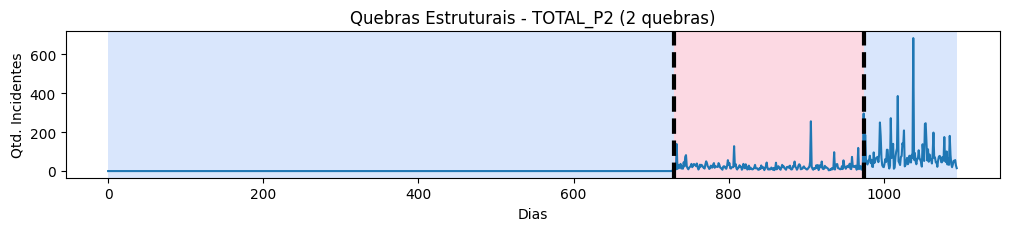


----------------------------------------
--- Analisando Coluna: TOTAL_P3 ---
----------------------------------------
Buscando exatamente 2 quebra(s)...
Quebra 1: 06/01/2025 (Índice: 735)
Quebra 2: 29/08/2025 (Índice: 970)

--- VALIDAÇÃO ESTATÍSTICA: TOTAL_P3 ---

Quebra 1 na data: 06/01/2025
  Média Antes: 0.78 incidentes/dia
  Média Depois: 69.75 incidentes/dia
  P-Valor: 0.0000
  Conclusão: ✅ Quebra ESTATISTICAMENTE VÁLIDA (Mudança real de patamar).

Quebra 2 na data: 29/08/2025
  Média Antes: 69.75 incidentes/dia
  Média Depois: 198.14 incidentes/dia
  P-Valor: 0.0000
  Conclusão: ✅ Quebra ESTATISTICAMENTE VÁLIDA (Mudança real de patamar).


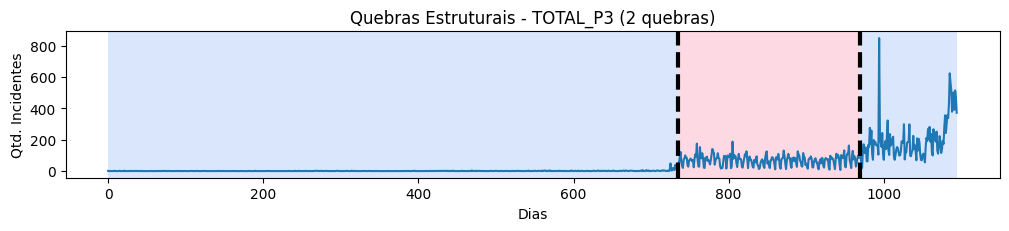


----------------------------------------
--- Analisando Coluna: TOTAL_P4 ---
----------------------------------------
Buscando exatamente 2 quebra(s)...
Quebra 1: 27/12/2024 (Índice: 725)
Quebra 2: 03/09/2025 (Índice: 975)

--- VALIDAÇÃO ESTATÍSTICA: TOTAL_P4 ---

Quebra 1 na data: 27/12/2024
  Média Antes: 0.25 incidentes/dia
  Média Depois: 28.97 incidentes/dia
  P-Valor: 0.0000
  Conclusão: ✅ Quebra ESTATISTICAMENTE VÁLIDA (Mudança real de patamar).

Quebra 2 na data: 03/09/2025
  Média Antes: 28.97 incidentes/dia
  Média Depois: 478.37 incidentes/dia
  P-Valor: 0.0000
  Conclusão: ✅ Quebra ESTATISTICAMENTE VÁLIDA (Mudança real de patamar).


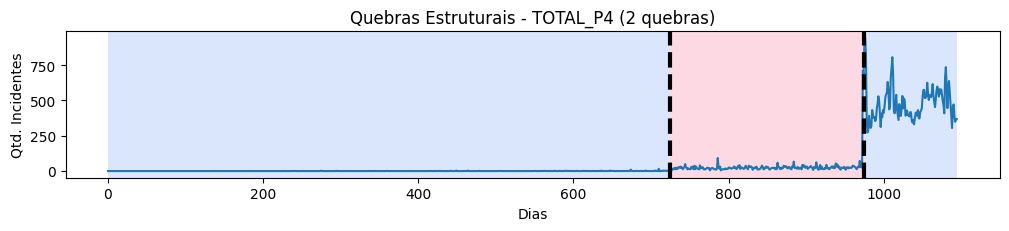


----------------------------------------
--- Analisando Coluna: TOTAL_INCIDENTES ---
----------------------------------------
Buscando exatamente 2 quebra(s)...
Quebra 1: 01/01/2025 (Índice: 730)
Quebra 2: 03/09/2025 (Índice: 975)

--- VALIDAÇÃO ESTATÍSTICA: TOTAL_INCIDENTES ---

Quebra 1 na data: 01/01/2025
  Média Antes: 1.00 incidentes/dia
  Média Depois: 124.14 incidentes/dia
  P-Valor: 0.0000
  Conclusão: ✅ Quebra ESTATISTICAMENTE VÁLIDA (Mudança real de patamar).

Quebra 2 na data: 03/09/2025
  Média Antes: 124.14 incidentes/dia
  Média Depois: 761.63 incidentes/dia
  P-Valor: 0.0000
  Conclusão: ✅ Quebra ESTATISTICAMENTE VÁLIDA (Mudança real de patamar).


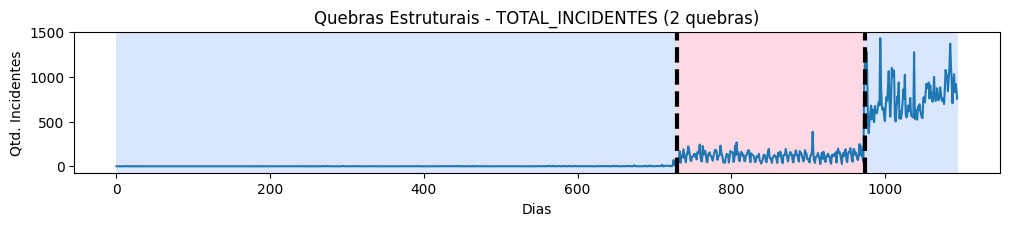

In [33]:
def encontrar_quebras_exatas(df, coluna_data, coluna_valor, n_quebras, min_tamanho=30):
    """
    Encontra um número exato de quebras estruturais em uma série temporal.
    min_tamanho garante que nenhuma quebra ocorra muito perto do fim ou início.
    """
    df_ordenado = df.sort_values(coluna_data).reset_index(drop=True)

    sinal = df_ordenado[coluna_valor].values

    # Algoritmo Dynp (Programação Dinâmica) buscando tamanho mínimo de patamar
    modelo = rpt.Dynp(model="rbf", min_size=min_tamanho).fit(sinal)

    # Prevemos usando o número EXATO de quebras (n_bkps)
    pontos_de_mudanca = modelo.predict(n_bkps=n_quebras)

    # Extraindo índices e datas
    indices_quebra = pontos_de_mudanca[:-1]
    datas_quebra = [df_ordenado[coluna_data].iloc[idx] for idx in indices_quebra]

    return datas_quebra, indices_quebra, sinal, pontos_de_mudanca

# Mapeamento do nome exato da coluna para o número de quebras observadas
config_quebras = {
    'total_p2': 2,
    'total_p3': 2,
    'total_p4': 2,
    'total_incidentes': 2  # Visão geral
}

for coluna, num_quebras_desejadas in config_quebras.items():
  print(f"\n{'-'*40}")
  print(f"--- Analisando Coluna: {coluna.upper()} ---")
  print(f"{'-'*40}")

  datas, indices, sinal, pts = encontrar_quebras_exatas(
      df=df_diario,
      coluna_data='data',
      coluna_valor=coluna,
      n_quebras=num_quebras_desejadas,
      min_tamanho=45
  )

  print(f"Buscando exatamente {num_quebras_desejadas} quebra(s)...")
  for i, data in enumerate(datas, start=1):
      print(f"Quebra {i}: {data.strftime('%d/%m/%Y')} (Índice: {indices[i-1]})")

  print(f"\n--- VALIDAÇÃO ESTATÍSTICA: {coluna.upper()} ---")

  # Adicionamos o índice 0 no início para facilitar o fatiamento dos blocos
  indices_fatiamento = [0] + indices + [len(sinal)]

  for i in range(len(indices)):
      # Definindo onde começa e termina o Bloco A (Antes) e o Bloco B (Depois)
      inicio_bloco_a = indices_fatiamento[i]
      fim_bloco_a = indices_fatiamento[i+1]
      fim_bloco_b = indices_fatiamento[i+2]

      bloco_a = sinal[inicio_bloco_a:fim_bloco_a]
      bloco_b = sinal[fim_bloco_a:fim_bloco_b]

      # Calculando as médias para visão de negócio
      media_a = np.mean(bloco_a)
      media_b = np.mean(bloco_b)

      # Aplicando o Teste de Mann-Whitney (melhor que Teste T para contagens)
      estatistica, p_valor = stats.mannwhitneyu(bloco_a, bloco_b, alternative='two-sided')

      print(f"\nQuebra {i+1} na data: {datas[i].strftime('%d/%m/%Y')}")
      print(f"  Média Antes: {media_a:.2f} incidentes/dia")
      print(f"  Média Depois: {media_b:.2f} incidentes/dia")
      print(f"  P-Valor: {p_valor:.4f}")

      # Interpretando o resultado estatístico (considerando alfa de 5%)
      if p_valor < 0.05:
          print("  Conclusão: ✅ Quebra ESTATISTICAMENTE VÁLIDA (Mudança real de patamar).")
      else:
          print("  Conclusão: ❌ Quebra INVÁLIDA / RUÍDO (As médias não são estatisticamente diferentes).")

  # Plotando os resultados
  fig, ax = rpt.display(sinal, pts, pts)
  plt.title(f"Quebras Estruturais - {coluna.upper()} ({num_quebras_desejadas} quebras)")
  plt.xlabel("Dias")
  plt.ylabel("Qtd. Incidentes")
  plt.show()

In [34]:
# Quebras escolhidas para análise de comportamento do target
q1 = "2025-01-01"
q2 = "2025-09-01"

In [35]:
# Criando o filtro de quebras pelo total de incidentes
def filtro_comportamentos(df, coluna_data, q1, q2):
    filtro_c1 = df[coluna_data] < pd.to_datetime(q1)
    filtro_c2 = ((df[coluna_data] >= pd.to_datetime(q1)) & (df[coluna_data] < pd.to_datetime(q2)))
    filtro_c3 = df[coluna_data] >= pd.to_datetime(q2)
    return [filtro_c1, filtro_c2, filtro_c3]
valores = [1, 2, 3]
df_diario['comportamento'] = np.select(filtro_comportamentos(df_diario, "data", q1, q2), valores, default=0)
df['comportamento'] = np.select(filtro_comportamentos(df, "data", q1, q2), valores, default=0)

### Comparação dos Comportamentos da Variável Target

In [36]:
# Calculando a contagem de incidentes e dias por comportamento
comparacao_comportamento = df_diario.groupby('comportamento').agg(
    total_incidentes=('total_incidentes', 'sum'),
    total_dias=('data', 'count')
)
comparacao_comportamento['media_incidentes_por_dia'] = comparacao_comportamento['total_incidentes'] / comparacao_comportamento['total_dias']
comparacao_comportamento['percentual_incidentes'] = (comparacao_comportamento['total_incidentes'] / comparacao_comportamento['total_incidentes'].sum()) * 100
comparacao_comportamento.head()

,total_incidentes,total_dias,media_incidentes_por_dia,percentual_incidentes
comportamento,,,,
1,732,730,1.002740,0.597341
2,28388,243,116.823045,23.165746
3,93423,122,765.762295,76.236913


In [37]:
# Gráfico de comparação de comportamento (Fator Crescimento Q1/Q2 e Q2/Q3)


In [38]:
# Comparação da variancia dos dados (std) entre os períodos de comportamento

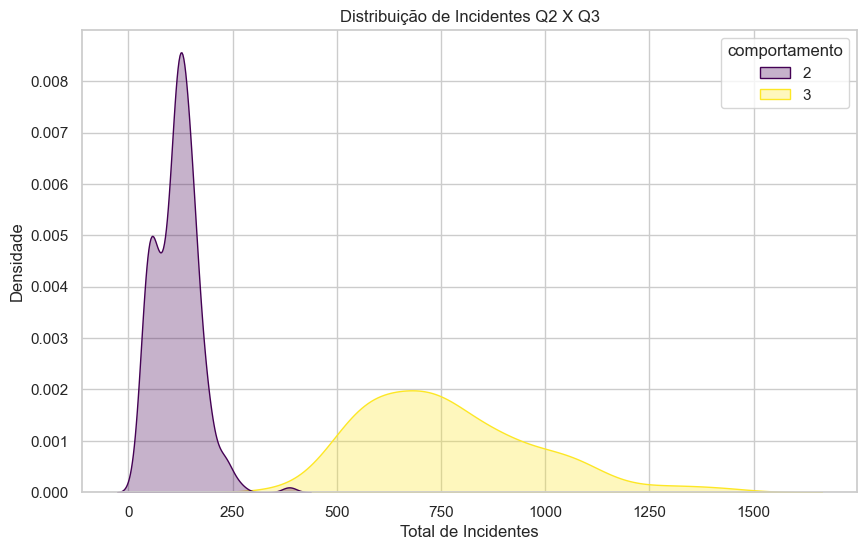

In [39]:
# Incidentes X Período
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df_diario[df_diario['comportamento']>1],
    x="total_incidentes",
    hue="comportamento",
    fill=True,
    common_norm=False,
    palette="viridis",
    alpha=0.3
)

plt.title("Distribuição de Incidentes Q2 X Q3")
plt.xlabel("Total de Incidentes")
plt.ylabel("Densidade")
plt.show()

In [40]:
incidentes_por_mes = df_diario.loc[df_diario['comportamento'] > 1].groupby('ano_mes').agg(
    total_incidentes=('total_incidentes', 'sum')
)

incidentes_por_mes_C1 = df_diario.loc[df_diario['comportamento'] == 1].groupby('ano_mes').agg(
    total_incidentes=('total_incidentes', 'sum')
)

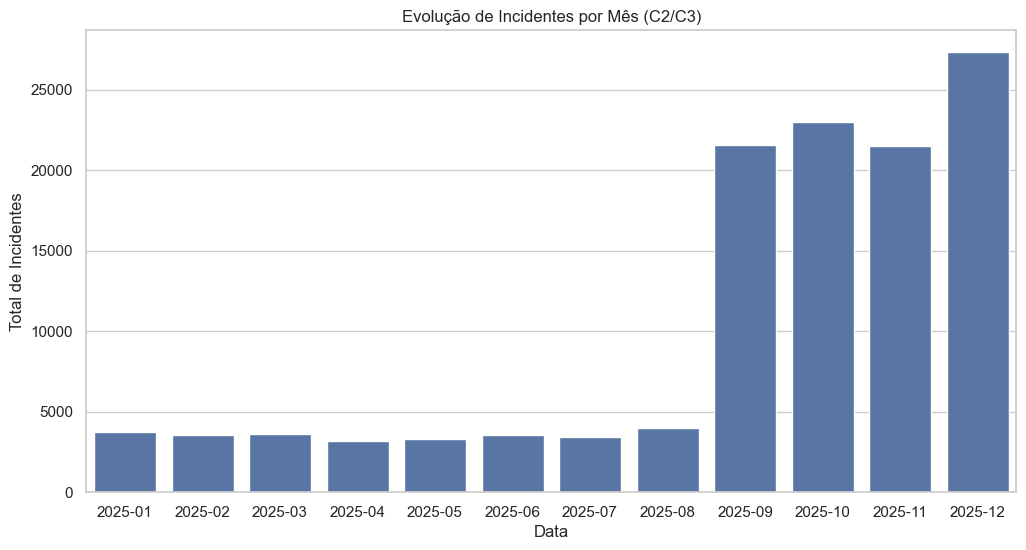

In [41]:
# Gráfico de número de incidentes por mês
plt.figure(figsize=(12, 6))
sns.barplot(data=incidentes_por_mes, x=incidentes_por_mes.index, y='total_incidentes')
plt.title("Evolução de Incidentes por Mês (C2/C3)")
plt.xlabel("Data")
plt.ylabel("Total de Incidentes")
plt.show()

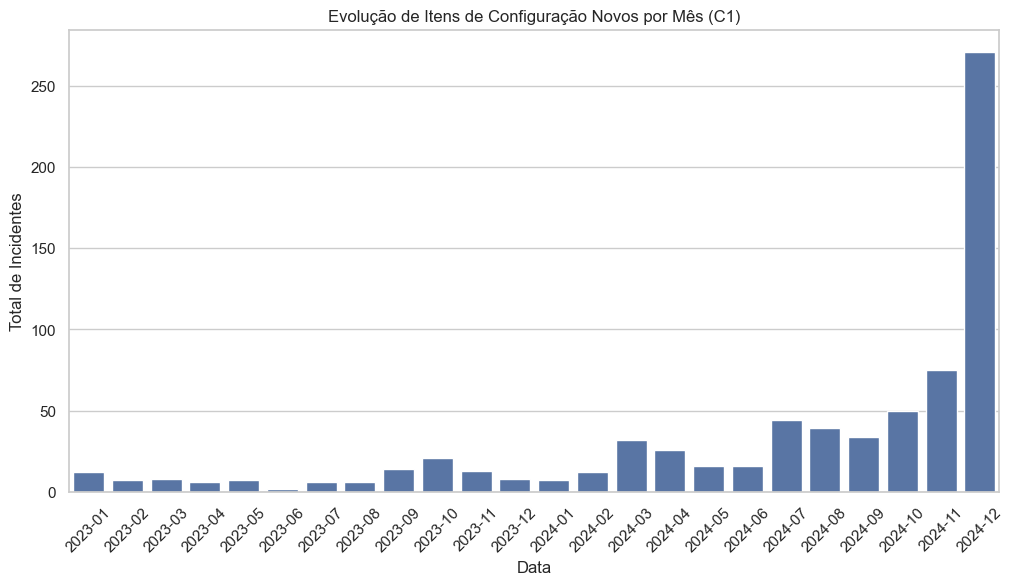

In [42]:
# Gráfico de número de incidentes por mês
plt.figure(figsize=(12, 6))
sns.barplot(data=incidentes_por_mes_C1, x=incidentes_por_mes_C1.index, y='total_incidentes')
plt.title("Evolução de Itens de Configuração Novos por Mês (C1)")
plt.xlabel("Data")
plt.ylabel("Total de Incidentes")
plt.xticks(rotation=45)
plt.show()

#### Comparando Sazonalidade
Foi realizada a comparação de dia util e final de semana/ feriado, e também a de dias da semana. Não foram realizadas análises de mês e trimestre, pois não há como comparar os dois de forma justa.

Tabela de Crescimento (Razão entre Q3 e Q2):
comportamento           2           3  fator_crescimento
tipo_dia                                                
dia_util       141.806061  807.267442           5.692757
fnds_feriado    63.974359  666.611111          10.419973


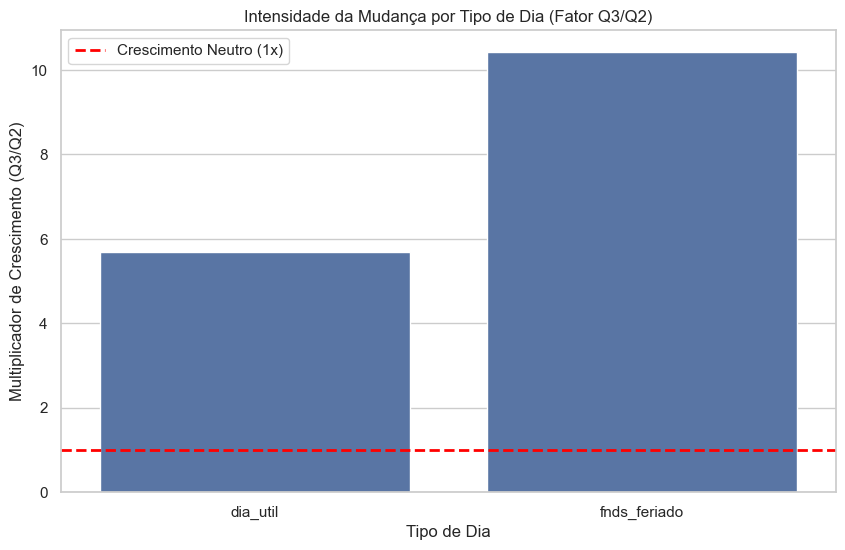

In [43]:
# Comparação Final de Semana X Feriado
df_agrupado = df_diario.groupby(['comportamento', 'tipo_dia', 'data'])['total_incidentes'].sum().reset_index()
df_taxa = df_agrupado.groupby(['comportamento', 'tipo_dia'])['total_incidentes'].mean().reset_index()

df_pivot = df_taxa[df_taxa['comportamento'].isin([2, 3])].pivot(
    index='tipo_dia', columns='comportamento', values='total_incidentes'
)
df_pivot['fator_crescimento'] = df_pivot[3] / df_pivot[2]

print("Tabela de Crescimento (Razão entre Q3 e Q2):")
print(df_pivot)

# Plotagem do Gráfico de Barras do Fator de Crescimento
plt.figure(figsize=(10, 6))

sns.barplot(
    x=df_pivot.index,
    y=df_pivot['fator_crescimento'],
)

# Linha de referência no 1.0 (crescimento neutro)
plt.axhline(1, color='red', linestyle='--', linewidth=2, label='Crescimento Neutro (1x)')

plt.title("Intensidade da Mudança por Tipo de Dia (Fator Q3/Q2)")
plt.ylabel("Multiplicador de Crescimento (Q3/Q2)")
plt.xlabel("Tipo de Dia")
plt.legend()
plt.show()

Fator de Crescimento por Dia da Semana (Q3 em relação a Q2):
comportamento           2           3  fator_crescimento
Seg            135.687500  806.055556           5.940529
Ter            138.757576  817.333333           5.890369
Qua            150.757576  819.666667           5.436985
Qui            159.727273  781.066667           4.890002
Sex            124.441176  807.882353           6.492082
Sáb             76.735294  693.500000           9.037562
Dom             49.714286  672.285714          13.522989


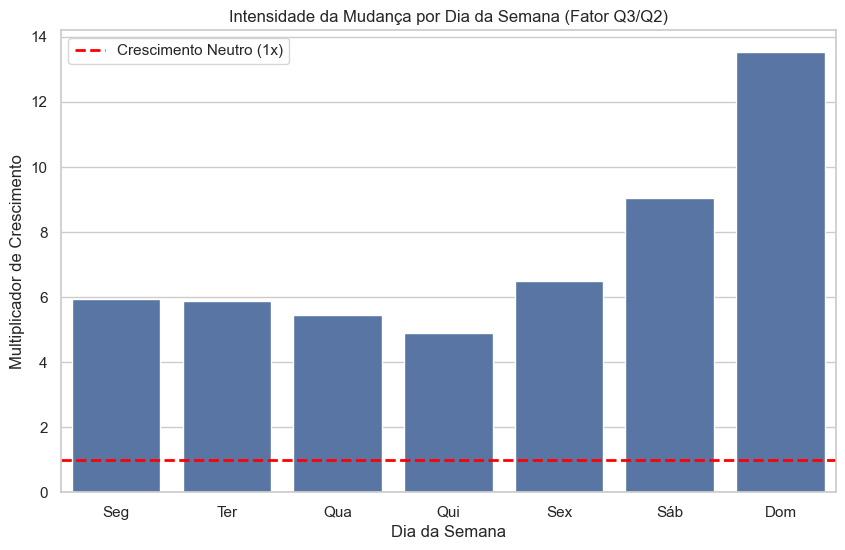

In [44]:
# Comparando dias da semana (removendo feriados)
df_uteis = df_diario[(df_diario['comportamento'].isin([2, 3])) & (df_diario['feriado'] == 0)].copy()

df_taxa_uteis = df_uteis.groupby(['comportamento', 'dia_semana'])['total_incidentes'].mean().reset_index()

df_pivot_uteis = df_taxa_uteis.pivot(index='dia_semana', columns='comportamento', values='total_incidentes')

df_pivot_uteis['fator_crescimento'] = df_pivot_uteis[3] / df_pivot_uteis[2]

df_pivot_uteis.index = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']
print("Fator de Crescimento por Dia da Semana (Q3 em relação a Q2):")
print(df_pivot_uteis)

plt.figure(figsize=(10, 6))

# Plotando as barras
sns.barplot(
    x=df_pivot_uteis.index,
    y=df_pivot_uteis['fator_crescimento']
)

# Adicionando uma linha horizontal no 1.0 (que representa estabilidade)
plt.axhline(1, color='red', linestyle='--', linewidth=2, label='Crescimento Neutro (1x)')

plt.title("Intensidade da Mudança por Dia da Semana (Fator Q3/Q2)")
plt.ylabel("Multiplicador de Crescimento")
plt.xlabel("Dia da Semana")
plt.legend()
plt.show()

#### Comparações a partir de dados categoricos

In [45]:
stats_data = []

for col_name in colunas_categoricas:
    nulls    = df[col_name].isna().sum()
    distintos = df[col_name].nunique()
    pct_nulls = round(nulls / total_registros * 100, 2) if total_registros > 0 else 0.0
    stats_data.append({
        "coluna": col_name,
        "total_registros": total_registros,
        "distintos": distintos,
        "nulos": int(nulls),
        "pct_nulls": pct_nulls,
    })

df_info_cat = pd.DataFrame(stats_data).sort_values(["nulos","distintos"]).reset_index(drop=True)
display(df_info_cat)

,coluna,total_registros,distintos,nulos,pct_nulls
0,Aberto por,122543,2,0,0.00
1,Status,122543,4,0,0.00
2,Prioridade,122543,5,0,0.00
3,Grupo designado,122543,17,0,0.00
4,Descrição Resumida,122543,17787,0,0.00
5,Item de configuração,122543,9171,1780,1.45
6,Categoria,122543,141,77719,63.42
7,Subcategoria,122543,447,77720,63.42
8,Produto,122543,51,77935,63.60
9,Solução,122543,2,107243,87.51


* Nota para guiar a análise:

Tipo de analise:
- Colunas que vale verificar a frequência individual de valores entre os comportamentos: Aberto por, Status, Prioridade, Grupo Designado
- Colunas que vale identificar a porcentagem de nulos em relação ao total de incidentes: Categoria, Produto, Incidente Pai
- Colunas que vale identificar o número de distintos antes e depois: Item de configuração

Perguntas de negócio:
- O número de incidentes abertos por monitoramento / manual seguiram a mesma proproção entre os comportamentos?
*Isso pode revelar se houve uma captação maior de incidentes (ex: antes só cerca de 50% dos incidentes ram identificados por monitoramento, agora são mais de 80%)
- O número de incidentes com status encerrado automaticamente, encerrado, sem intervenção mudou muito entre os comportamentos? *Isso pode indicar que antes não haviam incidentes sem intervençao, ou algo desse tipo
- Por que o número de incidentes p4 aumentaram tanto, e em relação as outras prioridades?
- Os times que atuaram nos incidentes tiveram atuações muito distintas entre os comportamentos?
- Tiveram muitos itens de configuração novos?
- Qual a relação entre itens de configuração e Categoria / Produto? - é 1 pra 1, ou 1 pra n
- Quando começou a rastreabilidade de solução e incidente pai? Há alguma relação disso com os comportamentos?

Colunas que precisam ser descartadas da análise em um primeiro momento:
Descrição Resumida

##### Coluna "Item de configuração"

Hipótese 1: O número de itens de configuração novos no comportamento 3 pode indicar algumas prováveis causas do aumento de incidentes. A lógica é: se muitos itens de configuração começaram a gerar incidentes pela primeira vez a partir de setembro, isso pode significar que a locaweb fez uma grande implantação, ou que houve uma falha geral, ou que a plataforma de ITSM começou a rastrear muitos itens inéditos (atualização na plataforma).

Hipótese 2: A relação entre o número de itens novos X itens fechados (itens que pararam de dar problema) pode indicar mais um aspecto desse aumento, talvez itens antigos tenham continuado apresentando problemas, em uma proporção que fez os incidentes não tornarem a diminuir novamente.



In [46]:
df['Categoria_Subcategoria'] = df['Categoria'].astype(str) + '_' + df['Subcategoria'].astype(str)
df['Produto_Categoria_Subcategoria'] = df['Produto'].astype(str) + '_' + df['Categoria'].astype(str) + '_' + df['Subcategoria'].astype(str)

In [47]:
itens_config = df.groupby('Item de configuração').agg(
    total_incidentes=('Número', 'count'), # total de incidentes por item de configuração
    data_minima=('data', 'min'), # primeira data de incidente para cada item de configuração
    data_maxima=('data', 'max'), # última data de incidente para cada item de configuração
    cat_distintos=('Categoria', 'nunique'), # total de categorias distintas por item de configuração
    prod_distintos=('Produto', 'nunique'), # total de produtos distintos por item de configuração
    cat_subcat_distintos=('Categoria_Subcategoria', 'nunique'), # total de categorias_subcategorias distintas por item de configuração
    prod_cat_subcat_distintos=('Produto_Categoria_Subcategoria', 'nunique'), # total de produtos_categorias_subcategorias distintas por item de configuração
    times_distintos=('Grupo designado', 'nunique'), # total de times distintos por item de configuração
    total_incidentes_c1=('comportamento', lambda x: (x == 1).sum()), # total de incidentes no comportamento 1
    total_incidentes_c2=('comportamento', lambda x: (x == 2).sum()), # total de incidentes no comportamento 2
    total_incidentes_c3=('comportamento', lambda x: (x == 3).sum()) # total de incidentes no comportamento 3
).reset_index()

itens_config = itens_config.sort_values(by='total_incidentes', ascending=False)

itens_config.head(5)

,Item de configuração,total_incidentes,data_minima,data_maxima,cat_distintos,prod_distintos,cat_subcat_distintos,prod_cat_subcat_distintos,times_distintos,total_incidentes_c1,total_incidentes_c2,total_incidentes_c3
13,IC00014,6069,2025-09-01,2025-12-31,1,1,2,2,1,0,0,6069
18,IC00019,4435,2025-09-01,2025-12-31,2,2,4,4,2,0,0,4435
7,IC00008,4196,2025-02-06,2025-12-31,2,2,4,4,2,0,2,4194
348,IC00349,3271,2023-02-05,2025-12-29,22,16,105,114,9,11,2599,661
1,IC00002,3119,2025-09-01,2025-12-31,1,1,2,2,2,0,0,3119


In [48]:
# Respondendo a Pergunta: "Qual a relação entre item de configuração e produto/categoria/subcategoria/times?"
itens_config[['prod_distintos', 'cat_distintos', 'cat_subcat_distintos', 'prod_cat_subcat_distintos', 'times_distintos']].describe()

,prod_distintos,cat_distintos,cat_subcat_distintos,prod_cat_subcat_distintos,times_distintos
count,9171.000000,9171.000000,9171.000000,9171.000000,9171.000000
mean,0.957911,1.099226,2.009814,2.027696,1.265729
std,0.762518,1.035662,2.526784,2.658682,0.590493
min,0.000000,0.000000,1.000000,1.000000,1.000000
25%,1.000000,1.000000,1.000000,1.000000,1.000000
50%,1.000000,1.000000,1.000000,1.000000,1.000000
75%,1.000000,1.000000,2.000000,2.000000,1.000000
max,16.000000,24.000000,105.000000,114.000000,10.000000


Os itens de configuração podem impactar diferentes produtos e categorias. Eles também não estão associados diretamente a uma união das colunas.

In [49]:
itens_novos_por_dia = itens_config.groupby('data_minima').agg(
    total_itens_novos=('Item de configuração', 'count')
)

In [50]:
itens_novos_por_dia.head()

,total_itens_novos
data_minima,
2023-01-02,1
2023-01-09,1
2023-01-11,1
2023-01-16,1
2023-01-23,1


In [51]:
# Merge com df_diario para análise de comportamento de itens de configuração novos
df_diario = df_diario.merge(itens_novos_por_dia, left_on='data', right_index=True, how='left')
df_diario['total_itens_novos'] = df_diario['total_itens_novos'].fillna(0).astype(int)

In [52]:
df_diario.head()

,data,total_incidentes,total_p1,total_p2,total_p3,total_p4,total_p5,inc_ac_mes,inc_ac_ano,inc_kpi_violado,...,dia_semana,dia_util,mes,trimestre,dia_mes,num_dia_util,ano_mes,tipo_dia,comportamento,total_itens_novos
0,2023-01-02,1,0,0,1,0,0,1,1,0,...,0,1,1,1,2,1,2023-01,dia_util,1,1
1,2023-01-03,0,0,0,0,0,0,1,1,0,...,1,1,1,1,3,2,2023-01,dia_util,1,0
2,2023-01-04,0,0,0,0,0,0,1,1,0,...,2,1,1,1,4,3,2023-01,dia_util,1,0
3,2023-01-05,0,0,0,0,0,0,1,1,0,...,3,1,1,1,5,4,2023-01,dia_util,1,0
4,2023-01-06,0,0,0,0,0,0,1,1,0,...,4,1,1,1,6,5,2023-01,dia_util,1,0


In [53]:
fig = px.line(
      df_diario.loc[df_diario['comportamento'] > 1],
      x='data',
      y='total_itens_novos',
      title=f'<b>Evolução Diária de Itens de Configuração Novos</b>',
      labels={'data': 'Data', 'total_itens_novos': 'Quantidade de Itens Novos'}
  )

fig.update_traces(
    line=dict(color='#c0392b', width=1.5),
    hovertemplate='<b>Data:</b> %{x|%d/%m/%Y}<br><b>Itens de Configuração Novos:</b> %{y}<extra></extra>'
)

fig.update_layout(
    title_font_size=20,
    hovermode='x unified',
    plot_bgcolor='white',
    xaxis=dict(
        showgrid=True,
        gridcolor='#f0f0f0',
        nticks=15,
        tickformat='%b/%y',
        tickangle=45
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='#f0f0f0'
    ),
    width=1100,
    height=600
)
fig.show()

In [54]:
# Evolução a nível mensal
itens_novos_por_mes = df_diario.loc[df_diario['comportamento'] > 1].groupby('ano_mes').agg(
    total_itens_novos=('total_itens_novos', 'sum')
)

In [55]:
itens_novos_por_mes.head()

,total_itens_novos
ano_mes,
2025-01,1122
2025-02,739
2025-03,692
2025-04,497
2025-05,422


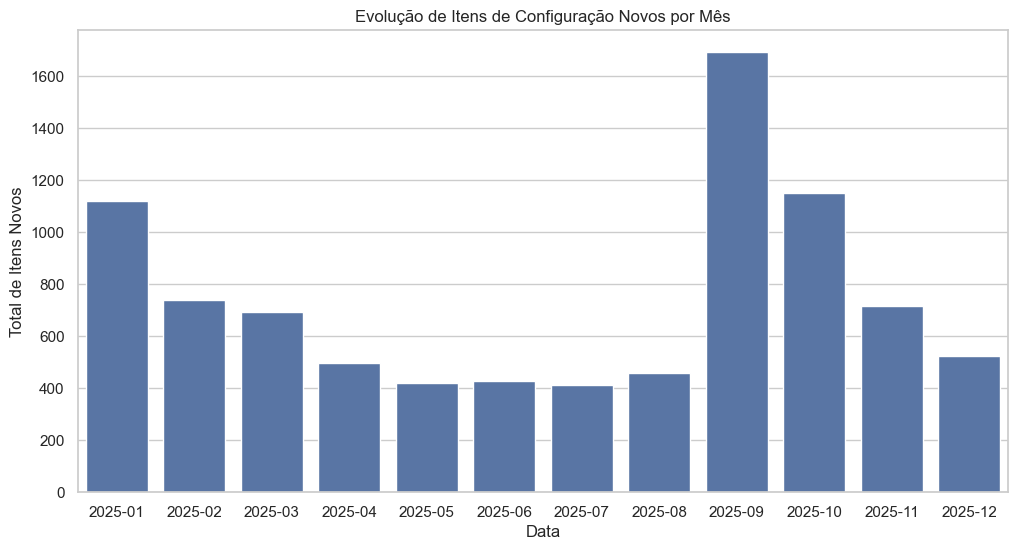

In [56]:
# Gráfico de barras (evolução de itens de configuração novos por dia)
plt.figure(figsize=(12, 6))
sns.barplot(data=itens_novos_por_mes, x=itens_novos_por_mes.index, y='total_itens_novos')
plt.title("Evolução de Itens de Configuração Novos por Mês")
plt.xlabel("Data")
plt.ylabel("Total de Itens Novos")
plt.show()

Sobre a Hipótese 1: realmente houve um aumento significativo no número de itens de configuração a partir de Setembro de 2025.

In [57]:
# Entendendo o cliclo de vida médio de um item de configuração (tempo entre o primeiro e último incidente)
itens_config['ciclo_vida_dias'] = (itens_config['data_maxima'] - itens_config['data_minima']).dt.days
# filtrando itens realmente inativos (sem incidentes nos últimos 30 dias)
data_maxima_geral = df_diario['data'].max()
itens_config_inativos = itens_config[itens_config['data_maxima'] < data_maxima_geral - pd.Timedelta(days=30)]
itens_config_inativos[['ciclo_vida_dias']].describe()

,ciclo_vida_dias
count,6978.000000
mean,50.233161
std,94.724137
min,0.000000
25%,0.000000
50%,0.000000
75%,56.000000
max,1042.000000


In [58]:
# Adicionando flag inativo para itens de configuração
itens_config['inativo'] = (itens_config['data_maxima'] < data_maxima_geral - pd.Timedelta(days=30)).astype(int)

In [59]:
itens_inativos_por_dia = itens_config[itens_config['inativo'] == 1].groupby('data_maxima').agg(
    total_itens_inativos=('Item de configuração', 'count')
)

In [60]:
itens_inativos_por_dia.head()

,total_itens_inativos
data_maxima,
2023-01-09,1
2023-03-17,1
2023-07-03,1
2023-07-11,1
2023-08-17,1


In [61]:
# Merge com df_diario para análise de comportamento de itens de configuração inativos
df_diario = df_diario.merge(itens_inativos_por_dia, left_on='data', right_index=True, how='left')
df_diario['total_itens_inativos'] = df_diario['total_itens_inativos'].fillna(0).astype(int)

In [62]:
itens_inativos_por_mes = df_diario.loc[df_diario['comportamento'] > 1].groupby('ano_mes').agg(
    total_itens_inativos=('total_itens_inativos', 'sum')
)

In [63]:
itens_inativos_por_mes.head()

,total_itens_inativos
ano_mes,
2025-01,378
2025-02,284
2025-03,336
2025-04,308
2025-05,296


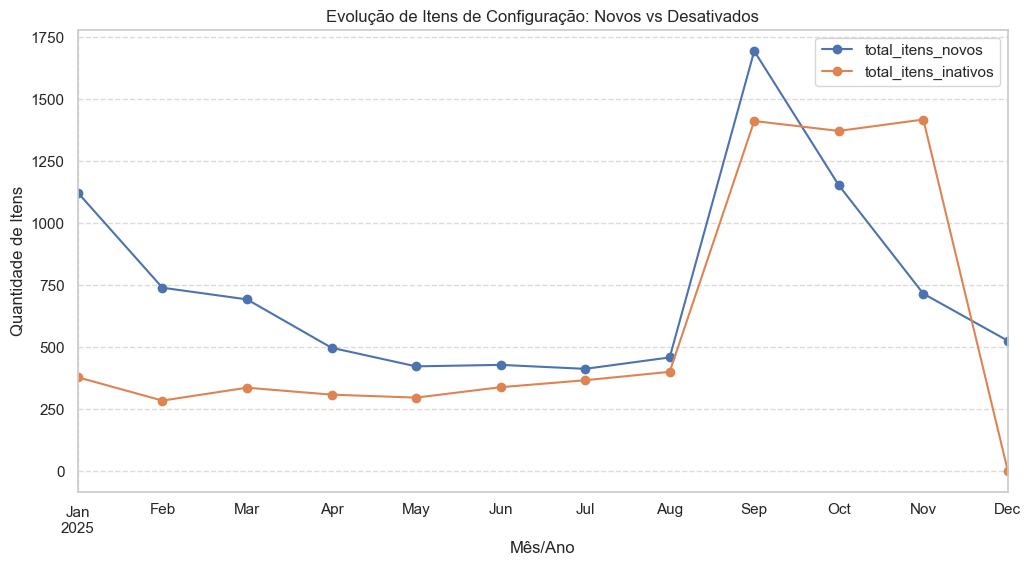

In [64]:
df_plot = pd.concat([itens_novos_por_mes, itens_inativos_por_mes], axis=1).fillna(0)
df_plot.index.name = 'Mes'
df_plot = df_plot.sort_index()

df_plot.plot(kind='line', marker='o', figsize=(12, 6))
plt.title('Evolução de Itens de Configuração: Novos vs Desativados')
plt.xlabel('Mês/Ano')
plt.ylabel('Quantidade de Itens')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

##### Coluna "Grupo designado"

In [ ]:
grupos_designados = df.groupby('Grupo designado').agg(
    total_incidentes=('Número', 'count'), # total de incidentes por grupo designado
    data_minima=('data', 'min'), # primeira data de incidente para cada grupo designado
    data_maxima=('data', 'max'), # última data de incidente para cada grupo designado
    cat_distintos=('Categoria', 'nunique'), # total de categorias distintas por grupo designado
    prod_distintos=('Produto', 'nunique'), # total de produtos distintos por grupo designado
    #cat_subcat_distintos=('Categoria_Subcategoria', 'nunique'), # total de categorias_subcategorias distintas por grupo designado
    #prod_cat_subcat_distintos=('Produto_Categoria_Subcategoria', 'nunique'), # total de produtos_categorias_subcategorias distintas por grupo designado
    ic_distintos=('Item de configuração', 'nunique'), # total de items de configuração distintos por grupo designado
    
    cat_distintos_c1=('Categoria', lambda x: df.loc[x.index[df.loc[x.index, 'comportamento'] == 1], 'Categoria'].nunique()), # total de categorias distintas no comportamento 1
    cat_distintos_c2=('Categoria', lambda x: df.loc[x.index[df.loc[x.index, 'comportamento'] == 2], 'Categoria'].nunique()), # total de categorias distintas no comportamento 2
    cat_distintos_c3=('Categoria', lambda x: df.loc[x.index[df.loc[x.index, 'comportamento'] == 3], 'Categoria'].nunique()), # total de categorias distintas no comportamento 3
    
    prod_distintos_c1=('Produto', lambda x: df.loc[x.index[df.loc[x.index, 'comportamento'] == 1], 'Produto'].nunique()), # total de produtos distintos no comportamento 1
    prod_distintos_c2=('Produto', lambda x: df.loc[x.index[df.loc[x.index, 'comportamento'] == 2], 'Produto'].nunique()), # total de produtos distintos no comportamento 2
    prod_distintos_c3=('Produto', lambda x: df.loc[x.index[df.loc[x.index, 'comportamento'] == 3], 'Produto'].nunique()), # total de produtos distintos no comportamento 3
    
    ic_distintos_c1=('Item de configuração', lambda x: df.loc[x.index[df.loc[x.index, 'comportamento'] == 1], 'Item de configuração'].nunique()), # total de items de configuração distintos no comportamento 1
    ic_distintos_c2=('Item de configuração', lambda x: df.loc[x.index[df.loc[x.index, 'comportamento'] == 2], 'Item de configuração'].nunique()), # total de items de configuração distintos no comportamento 2
    ic_distintos_c3=('Item de configuração', lambda x: df.loc[x.index[df.loc[x.index, 'comportamento'] == 3], 'Item de configuração'].nunique()), # total de items de configuração distintos no comportamento 3
    
    total_incidentes_c1=('comportamento', lambda x: (x == 1).sum()), # total de incidentes no comportamento 1
    total_incidentes_c2=('comportamento', lambda x: (x == 2).sum()), # total de incidentes no comportamento 2
    total_incidentes_c3=('comportamento', lambda x: (x == 3).sum()), # total de incidentes no comportamento 3

    inc_p1=('Prioridade_Ordinal', lambda x: (x == 1).sum()), # total de incidentes de prioridade 1
    inc_p2=('Prioridade_Ordinal', lambda x: (x == 2).sum()), # total de incidentes de prioridade 2
    inc_p3=('Prioridade_Ordinal', lambda x: (x == 3).sum()), # total de incidentes de prioridade 3
    inc_p4=('Prioridade_Ordinal', lambda x: (x == 4).sum()), # total de incidentes de prioridade 4
    inc_p5=('Prioridade_Ordinal', lambda x: (x == 5).sum()), # total de incidentes de prioridade 5

    inc_p1_c1=('Prioridade_Ordinal', lambda x: ((x == 1) & (df.loc[x.index, 'comportamento'] == 1)).sum()), # total de incidentes de prioridade 1 no comportamento 1
    inc_p2_c1=('Prioridade_Ordinal', lambda x: ((x == 2) & (df.loc[x.index, 'comportamento'] == 1)).sum()), # total de incidentes de prioridade 2 no comportamento 1
    inc_p3_c1=('Prioridade_Ordinal', lambda x: ((x == 3) & (df.loc[x.index, 'comportamento'] == 1)).sum()), # total de incidentes de prioridade 3 no comportamento 1
    inc_p4_c1=('Prioridade_Ordinal', lambda x: ((x == 4) & (df.loc[x.index, 'comportamento'] == 1)).sum()), # total de incidentes de prioridade 4 no comportamento 1
    inc_p5_c1=('Prioridade_Ordinal', lambda x: ((x == 5) & (df.loc[x.index, 'comportamento'] == 1)).sum()), # total de incidentes de prioridade 5 no comportamento 1

    inc_p1_c2=('Prioridade_Ordinal', lambda x: ((x == 1) & (df.loc[x.index, 'comportamento'] == 2)).sum()), # total de incidentes de prioridade 1 no comportamento 2
    inc_p2_c2=('Prioridade_Ordinal', lambda x: ((x == 2) & (df.loc[x.index, 'comportamento'] == 2)).sum()), # total de incidentes de prioridade 2 no comportamento 2
    inc_p3_c2=('Prioridade_Ordinal', lambda x: ((x == 3) & (df.loc[x.index, 'comportamento'] == 2)).sum()), # total de incidentes de prioridade 3 no comportamento 2
    inc_p4_c2=('Prioridade_Ordinal', lambda x: ((x == 4) & (df.loc[x.index, 'comportamento'] == 2)).sum()), # total de incidentes de prioridade 4 no comportamento 2
    inc_p5_c2=('Prioridade_Ordinal', lambda x: ((x == 5) & (df.loc[x.index, 'comportamento'] == 2)).sum()), # total de incidentes de prioridade 5 no comportamento 2
    
    inc_p1_c3=('Prioridade_Ordinal', lambda x: ((x == 1) & (df.loc[x.index, 'comportamento'] == 3)).sum()), # total de incidentes de prioridade 1 no comportamento 3
    inc_p2_c3=('Prioridade_Ordinal', lambda x: ((x == 2) & (df.loc[x.index, 'comportamento'] == 3)).sum()), # total de incidentes de prioridade 2 no comportamento 3
    inc_p3_c3=('Prioridade_Ordinal', lambda x: ((x == 3) & (df.loc[x.index, 'comportamento'] == 3)).sum()), # total de incidentes de prioridade 3 no comportamento 3
    inc_p4_c3=('Prioridade_Ordinal', lambda x: ((x == 4) & (df.loc[x.index, 'comportamento'] == 3)).sum()), # total de incidentes de prioridade 4 no comportamento 3
    inc_p5_c3=('Prioridade_Ordinal', lambda x: ((x == 5) & (df.loc[x.index, 'comportamento'] == 3)).sum()) # total de incidentes de prioridade 5 no comportamento 3
).reset_index()

grupos_designados = grupos_designados.sort_values(by='total_incidentes', ascending=False)
grupos_designados['pct_incidentes_geral'] = round((grupos_designados['total_incidentes'] / total_registros), 4) * 100 # percentual de incidentes do grupo designado em relação ao total de incidentes

# Percentual de incidentes por comportamento em relação ao total de incidentes do periodo do comportamento (C1, C2, C3)
grupos_designados['pct_inc_c1_geral'] = round((grupos_designados['total_incidentes_c1'] / grupos_designados['total_incidentes_c1'].sum()), 4) * 100
grupos_designados['pct_inc_c2_geral'] = round((grupos_designados['total_incidentes_c2'] / grupos_designados['total_incidentes_c2'].sum()), 4) * 100
grupos_designados['pct_inc_c3_geral'] = round((grupos_designados['total_incidentes_c3'] / grupos_designados['total_incidentes_c3'].sum()), 4) * 100

# Percentual de incidentes por prioridade em relação ao total de incidentes por prioridade (P1, P2, P3, P4, P5)
grupos_designados['pct_inc_p1_c1_geral'] = round((grupos_designados['inc_p1_c1'] / grupos_designados['inc_p1'].sum()), 4) * 100
grupos_designados['pct_inc_p2_c1_geral'] = round((grupos_designados['inc_p2_c1'] / grupos_designados['inc_p2'].sum()), 4) * 100
grupos_designados['pct_inc_p3_c1_geral'] = round((grupos_designados['inc_p3_c1'] / grupos_designados['inc_p3'].sum()), 4) * 100
grupos_designados['pct_inc_p4_c1_geral'] = round((grupos_designados['inc_p4_c1'] / grupos_designados['inc_p4'].sum()), 4) * 100
grupos_designados['pct_inc_p5_c1_geral'] = round((grupos_designados['inc_p5_c1'] / grupos_designados['inc_p5'].sum()), 4) * 100

grupos_designados['pct_inc_p1_c2_geral'] = round((grupos_designados['inc_p1_c2'] / grupos_designados['inc_p1'].sum()), 4) * 100
grupos_designados['pct_inc_p2_c2_geral'] = round((grupos_designados['inc_p2_c2'] / grupos_designados['inc_p2'].sum()), 4) * 100
grupos_designados['pct_inc_p3_c2_geral'] = round((grupos_designados['inc_p3_c2'] / grupos_designados['inc_p3'].sum()), 4) * 100
grupos_designados['pct_inc_p4_c2_geral'] = round((grupos_designados['inc_p4_c2'] / grupos_designados['inc_p4'].sum()), 4) * 100
grupos_designados['pct_inc_p5_c2_geral'] = round((grupos_designados['inc_p5_c2'] / grupos_designados['inc_p5'].sum()), 4) * 100

grupos_designados['pct_inc_p1_c3_geral'] = round((grupos_designados['inc_p1_c3'] / grupos_designados['inc_p1'].sum()), 4) * 100
grupos_designados['pct_inc_p2_c3_geral'] = round((grupos_designados['inc_p2_c3'] / grupos_designados['inc_p2'].sum()), 4) * 100
grupos_designados['pct_inc_p3_c3_geral'] = round((grupos_designados['inc_p3_c3'] / grupos_designados['inc_p3'].sum()), 4) * 100 
grupos_designados['pct_inc_p4_c3_geral'] = round((grupos_designados['inc_p4_c3'] / grupos_designados['inc_p4'].sum()), 4) * 100
grupos_designados['pct_inc_p5_c3_geral'] = round((grupos_designados['inc_p5_c3'] / grupos_designados['inc_p5'].sum()), 4) * 100

# Percentual de incidentes por comportamento em relação ao total de incidentes do grupo designado (C1, C2, C3)
grupos_designados['pct_inc_c1_proprio'] = round((grupos_designados['total_incidentes_c1'] / grupos_designados['total_incidentes']), 4) * 100
grupos_designados['pct_inc_c2_proprio'] = round((grupos_designados['total_incidentes_c2'] / grupos_designados['total_incidentes']), 4) * 100
grupos_designados['pct_inc_c3_proprio'] = round((grupos_designados['total_incidentes_c3'] / grupos_designados['total_incidentes']), 4) * 100

# Percentual de incidentes por prioridade em relação ao total de incidentes por prioridade (P1, P2, P3, P4, P5) e em relação ao total de incidentes do grupo designado
grupos_designados['pct_inc_p1_proprio'] = round((grupos_designados['inc_p1'] / grupos_designados['total_incidentes']), 4) * 100
grupos_designados['pct_inc_p2_proprio'] = round((grupos_designados['inc_p2'] / grupos_designados['total_incidentes']), 4) * 100
grupos_designados['pct_inc_p3_proprio'] = round((grupos_designados['inc_p3'] / grupos_designados['total_incidentes']), 4) * 100
grupos_designados['pct_inc_p4_proprio'] = round((grupos_designados['inc_p4'] / grupos_designados['total_incidentes']), 4) * 100
grupos_designados['pct_inc_p5_proprio'] = round((grupos_designados['inc_p5'] / grupos_designados['total_incidentes']), 4) * 100

grupos_designados['pct_inc_p1_c1_proprio'] = round((grupos_designados['inc_p1_c1'] / grupos_designados['total_incidentes_c1']), 4) * 100
grupos_designados['pct_inc_p2_c1_proprio'] = round((grupos_designados['inc_p2_c1'] / grupos_designados['total_incidentes_c1']), 4) * 100
grupos_designados['pct_inc_p3_c1_proprio'] = round((grupos_designados['inc_p3_c1'] / grupos_designados['total_incidentes_c1']), 4) * 100
grupos_designados['pct_inc_p4_c1_proprio'] = round((grupos_designados['inc_p4_c1'] / grupos_designados['total_incidentes_c1']), 4) * 100
grupos_designados['pct_inc_p5_c1_proprio'] = round((grupos_designados['inc_p5_c1'] / grupos_designados['total_incidentes_c1']), 4) * 100

grupos_designados['pct_inc_p1_c2_proprio'] = round((grupos_designados['inc_p1_c2'] / grupos_designados['total_incidentes_c2']), 4) * 100
grupos_designados['pct_inc_p2_c2_proprio'] = round((grupos_designados['inc_p2_c2'] / grupos_designados['total_incidentes_c2']), 4) * 100
grupos_designados['pct_inc_p3_c2_proprio'] = round((grupos_designados['inc_p3_c2'] / grupos_designados['total_incidentes_c2']), 4) * 100
grupos_designados['pct_inc_p4_c2_proprio'] = round((grupos_designados['inc_p4_c2'] / grupos_designados['total_incidentes_c2']), 4) * 100
grupos_designados['pct_inc_p5_c2_proprio'] = round((grupos_designados['inc_p5_c2'] / grupos_designados['total_incidentes_c2']), 4) * 100

grupos_designados['pct_inc_p1_c3_proprio'] = round((grupos_designados['inc_p1_c3'] / grupos_designados['total_incidentes_c3']), 4) * 100
grupos_designados['pct_inc_p2_c3_proprio'] = round((grupos_designados['inc_p2_c3'] / grupos_designados['total_incidentes_c3']), 4) * 100
grupos_designados['pct_inc_p3_c3_proprio'] = round((grupos_designados['inc_p3_c3'] / grupos_designados['total_incidentes_c3']), 4) * 100
grupos_designados['pct_inc_p4_c3_proprio'] = round((grupos_designados['inc_p4_c3'] / grupos_designados['total_incidentes_c3']), 4) * 100
grupos_designados['pct_inc_p5_c3_proprio'] = round((grupos_designados['inc_p5_c3'] / grupos_designados['total_incidentes_c3']), 4) * 100

grupos_designados.head(17)

,Grupo designado,total_incidentes,data_minima,data_maxima,cat_distintos,prod_distintos,ic_distintos,cat_distintos_c1,cat_distintos_c2,cat_distintos_c3,...,inc_p3_c3,inc_p4_c3,inc_p5_c3,pct_incidentes_geral,pct_inc_c1_geral,pct_inc_c2_geral,pct_inc_c3_geral,pct_inc_c1_proprio,pct_inc_c2_proprio,pct_inc_c3_proprio
13,Team14,92775,2023-01-09,2025-12-31,73,29,6658,24,67,59,...,16718,57192,14,75.71,13.93,38.59,87.47,0.11,11.81,88.08
10,Team11,9790,2023-01-11,2025-12-30,66,35,661,17,60,45,...,2198,185,0,7.99,8.47,25.82,2.57,0.63,74.87,24.49
4,Team05,9276,2023-01-30,2025-12-30,49,20,947,23,44,34,...,2556,118,0,7.57,42.90,17.80,4.19,3.39,54.46,42.15
8,Team09,3425,2023-02-09,2025-12-31,65,28,1290,23,56,53,...,501,348,3,2.79,23.22,7.41,1.23,4.96,61.40,33.64
11,Team12,2173,2024-03-19,2025-12-31,49,29,423,5,39,29,...,1197,5,0,1.77,1.09,2.36,1.60,0.37,30.88,68.75
2,Team03,1306,2024-11-19,2025-12-31,52,25,442,2,44,34,...,119,534,0,1.07,0.41,1.92,0.81,0.23,41.65,58.12
9,Team10,1172,2024-12-24,2025-12-31,12,10,178,1,10,4,...,867,49,0,0.96,0.27,0.44,1.12,0.17,10.75,89.08
16,Team17,743,2023-05-20,2025-12-26,35,17,377,7,32,23,...,136,56,0,0.61,3.01,1.68,0.26,2.96,64.33,32.71
1,Team02,579,2023-08-30,2025-12-30,32,15,248,2,26,21,...,54,176,0,0.47,0.55,1.10,0.28,0.69,53.71,45.60
0,Team01,306,2024-12-29,2025-12-26,25,10,106,1,24,13,...,91,21,3,0.25,0.14,0.67,0.12,0.33,61.76,37.91


In [83]:
df_plot.head()

,Grupo designado,pct_inc_c1_geral,pct_inc_c2_geral,pct_inc_c3_geral
0,Outros,100.01,100.0,99.99


In [86]:
import plotly.graph_objects as go

# Exemplo simplificado para uma equipe ou comparativo
fig = go.Figure()
for equipe in grupos_designados['Grupo designado']:
    fig.add_trace(go.Scatter(x=['C1', 'C2', 'C3'], 
                             y=[grupos_designados.loc[grupos_designados['Grupo designado']==equipe, 'pct_inc_c1_geral'].values[0],
                                grupos_designados.loc[grupos_designados['Grupo designado']==equipe, 'pct_inc_c2_geral'].values[0],
                                grupos_designados.loc[grupos_designados['Grupo designado']==equipe, 'pct_inc_c3_geral'].values[0]],
                             mode='lines+markers', name=equipe))
fig.show()